<a href="https://colab.research.google.com/github/shinae1023/AML_project/blob/main/earlyexit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/biggsbenjamin/earlyexitnet
%cd earlyexitnet

Cloning into 'earlyexitnet'...
remote: Enumerating objects: 953, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 953 (delta 104), reused 168 (delta 76), pack-reused 738 (from 2)
Receiving objects: 100% (953/953), 84.70 MiB | 17.06 MiB/s, done.
Resolving deltas: 100% (496/496), done.
Updating files: 100% (58/58), done.
/content/earlyexitnet


In [2]:
!apt-get update
!apt-get install protobuf-compiler libprotoc-dev

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,292 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-upda

In [3]:
!pip install .

Processing /content/earlyexitnet
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!python -m earlyexitnet.cli -m b_lenet_se -d mnist -bbe 50 -jte 30 -bstr 500 -rn "my_scratch_lenet" -gpu 0 -nw 4

Model done: b_lenet_se
Model done: b_lenet_se
Device: cuda:0
Number of workers: 4
Loss function set
Training new network
pin memory = True
100% 9.91M/9.91M [00:02<00:00, 4.04MB/s]
100% 28.9k/28.9k [00:00<00:00, 132kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100% 4.54k/4.54k [00:00<00:00, 13.9MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Got training data, batch size: 500
backbone epochs: 50 joint epochs: 30
using bb optimiser -> adam-brn
using jt optimiser -> adam-brn
PRETRAINING BACKBONE FROM SCRATCH
Training final exit
Starting epoch: 1... /usr/local

In [7]:
# 1. 안전하게 디렉토리를 먼저 다시 생성함
!mkdir -p outputs/b_lenet_se/range_notes

# 2. 경로에서 ./를 제외하고 가중치 파일 위치를 지정하여 스캔을 실행함
!python -m earlyexitnet.cli -m b_lenet_se -d mnist -mp outputs/b_lenet_se/pre_Trn_bb_2026-05-19_140717/pretrn-joint-e27-2026-05-19_141710.pth -tr 0.1 0.99 -ts 0.05 -bste 500 -np outputs/b_lenet_se/range_notes/ -gpu 0 -nw 2

Model done: b_lenet_se
Model: b_lenet_se
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2


In [9]:
import re

cli_path = "/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py"

with open(cli_path, "r", encoding="utf-8") as f:
    content = f.read()

# 정규식을 이용해 net_test = Tester(...) 부분을 통째로 찾아서 명시적 키워드 인자로 교체
pattern = re.compile(r'net_test\s*=\s*Tester\s*\([^)]*\)', re.DOTALL)

fixed_code = """net_test = Tester(
        model=model,
        test_dl=test_dl,
        loss_f=loss_f,
        exits=exits,
        top1acc_thresholds=top1_thr,
        entropy_thresholds=entr_thr,
        conf_funcs=args.confidence_function,
        device=device,
        save_raw=save_raw
    )"""

if pattern.search(content):
    new_content = pattern.sub(fixed_code, content)
    with open(cli_path, "w", encoding="utf-8") as f:
        f.write(new_content)
    print("✅ [성공] cli.py 내부 인자 매핑을 완벽하게 강제 패치했음.")
else:
    print("❌ [실패] 변경할 부분을 찾지 못했음.")

✅ [성공] cli.py 내부 인자 매핑을 완벽하게 강제 패치했음.


In [11]:
!python -m earlyexitnet.cli -m b_lenet_se -d mnist -mp outputs/b_lenet_se/pre_Trn_bb_2026-05-19_140717/pretrn-joint-e27-2026-05-19_141710.pth -t1 0 -entr 0 -tr 0.1 0.99 -ts 0.05 -bste 500 -np outputs/b_lenet_se/range_notes/ -gpu 0 -nw 2 -cf 1

Model done: b_lenet_se
Model: b_lenet_se
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/17, thresh: 0.1 		 [00:00/00:00]
Devi

📈 로드된 데이터 파일: ./outputs/b_lenet_se/range_notes/b_lenet_se_multiple_2026-05-19_143651.json


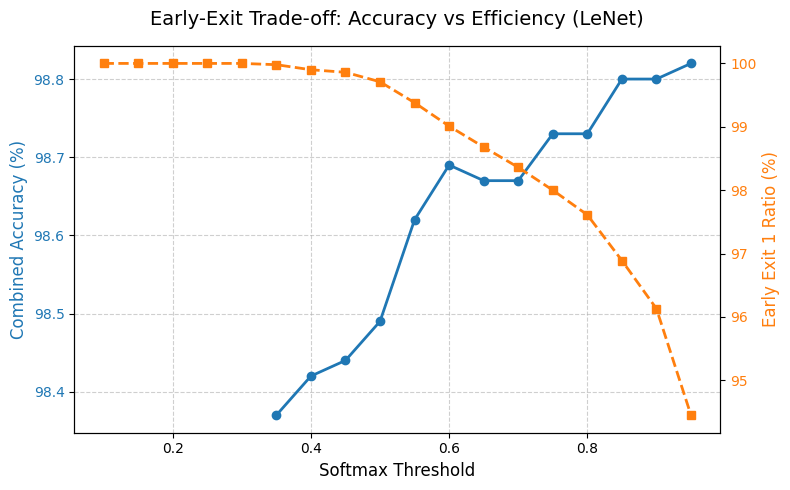

In [13]:
import json
import glob
import os
import matplotlib.pyplot as plt

# 지정된 경로에서 가장 최근에 생성된 다중 스캔 json 결과 파일 탐색
json_files = glob.glob("./outputs/b_lenet_se/range_notes/*multiple*.json")
if json_files:
    latest_json = max(json_files, key=os.path.getctime)
    print(f"📈 로드된 데이터 파일: {latest_json}")

    with open(latest_json, "r") as f:
        data = json.load(f)

    # 지표 데이터 파싱
    test_vals = data["test_vals"]
    thresholds = [item["conf_metrics"]["_thr_max_softmax"]["exit_threshs"][0] for item in test_vals]
    accuracies = [item["conf_metrics"]["_thr_max_softmax"]["combined_accuracy"] * 100 for item in test_vals]
    early_exit_pct = [item["conf_metrics"]["_thr_max_softmax"]["exit_pc"][0] * 100 for item in test_vals]

    # 그래프 생성
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # 왼쪽 Y축: 전체 연산 정확도 (Accuracy)
    color = 'tab:blue'
    ax1.set_xlabel('Softmax Threshold', fontsize=12)
    ax1.set_ylabel('Combined Accuracy (%)', color=color, fontsize=12)
    ax1.plot(thresholds, accuracies, color=color, marker='o', linewidth=2, label='Accuracy')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 오른쪽 Y축: Early Exit 1번 분기에서 조기 종료된 데이터 비중 (Efficiency)
    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Early Exit 1 Ratio (%)', color=color, fontsize=12)
    ax2.plot(thresholds, early_exit_pct, color=color, marker='s', linestyle='--', linewidth=2, label='EE1 Ratio')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Early-Exit Trade-off: Accuracy vs Efficiency (LeNet)', fontsize=14, pad=15)
    fig.tight_layout()
    plt.show()
else:
    print("❌ 스캔 결과 JSON 파일을 발견하지 못했습니다.")



---

alexnet

In [15]:
import os

train_path = "/usr/local/lib/python3.12/dist-packages/earlyexitnet/training_tools/train.py"

if os.path.exists(train_path):
    with open(train_path, "r", encoding="utf-8") as f:
        content = f.read()

    # 1. AlexNet 클래스 임포트 추가
    if "B_Alexnet_cifar" not in content:
        content = content.replace("B_Lenet_cifar", "B_Lenet_cifar, B_Alexnet_cifar")

    # 2. get_model 함수에 AlexNet 연결고리 추가
    if "'b_alexnet_cifar'" not in content:
        target = "elif model_str == 'resnet8':"
        insertion = (
            "elif model_str == 'b_alexnet_cifar':\n"
            "        model = B_Alexnet_cifar()\n    "
        )
        content = content.replace(target, insertion + target)

    with open(train_path, "w", encoding="utf-8") as f:
        f.write(content)
    print("[성공]")
else:
    print("train.py 경로를 찾을 수 없습니다.")

[성공]


In [ ]:
!python -m earlyexitnet.cli -m b_alexnet_cifar -d cifar10 -bbe 50 -jte 30 -bstr 256 -rn "my_scratch_alexnet" -gpu 0 -nw 2 -t1 0 -entr 0

Model done: b_alexnet_cifar
Model done: b_alexnet_cifar
Device: cuda:0
Number of workers: 2
Loss function set
Training new network
pin memory = True
Got training data, batch size: 256
backbone epochs: 50 joint epochs: 30
using bb optimiser -> adam-brn
using jt optimiser -> adam-brn
PRETRAINING BACKBONE FROM SCRATCH
Training final exit
Starting epoch: 1... raw t loss:0.008773663934941093 t1acc:0.13774539262820512
raw v loss:0.008196017681024013 v accu:0.1780849358974359
Saved to: outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-19_145752/backbone-e1-2026-05-19_145835.pth
Starting epoch: 2... raw t loss:0.007931519923612284 t1acc:0.19050480769230768
raw v loss:0.007526276203302236 v accu:0.22806490384615385
Saved to: outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-19_145752/backbone-e2-2026-05-19_145919.pth
Starting epoch: 3... raw t loss:0.007509580165601502 t1acc:0.2281650641025641
raw v loss:0.0072617660730313035 v accu:0.26732772435897434
Saved to: outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-19_

In [ ]:
!nvidia-smi